In [1]:
# === CELL 1: LOAD FAIRLEARN CREDIT CARD DATASET ===
from fairlearn.datasets import fetch_credit_card
import pandas as pd
import numpy as np

print("Loading Default of Credit Card Clients Dataset...")
data = fetch_credit_card(as_frame=True)
X = data.data
y = data.target

print(f"🎉 Dataset loaded safely! Total rows: {X.shape[0]}")

Loading Default of Credit Card Clients Dataset...
🎉 Dataset loaded safely! Total rows: 30000


In [2]:
# # === CELL 2: GENDER PREPROCESSING FOR CREDIT LENDING (FIXED) ===
# import pandas as pd
# import numpy as np
# from sklearn.model_selection import train_test_split
# from sklearn.linear_model import LogisticRegression
# from sklearn.ensemble import RandomForestClassifier
# from xgboost import XGBClassifier

# # 1. Dynamically locate the Gender/Sex column safely
# gender_col = None
# for col in X.columns:
#     if col.upper() in ['SEX', 'GENDER', 'X2']:
#         gender_col = col
#         break

# if gender_col is None:
#     gender_col = X.columns[1]

# print(f"Detected Gender Column Name: '{gender_col}'")

# # Map Gender: Female = 1, Male = 0
# sensitive_gender = np.where((X[gender_col] == 2) | (X[gender_col] == '2') | (X[gender_col].astype(str).str.lower().str.startswith('f')), 1, 0)

# # 2. Fix the target variable
# y_clean = y.astype(int).values

# # 3. Convert remaining columns to numbers (Keep gender column in X_features for the loop)
# X_encoded = pd.get_dummies(X, drop_first=True)

# print("\n--- ⚧ Your Lending Gender Group Split ---")
# print(pd.Series(sensitive_gender).value_counts().rename({1: 'Female', 0: 'Male'}))

# # 4. Split into Train and Test sets safely
# X_train, X_test, y_train, y_test, sensitive_train, sensitive_test = train_test_split(
#     X_encoded, y_clean, sensitive_gender, test_size=0.2, random_state=42, stratify=y_clean
# )

# # Align variables to match your Cell 5 loop configuration perfectly
# sensitive_train = pd.Series(sensitive_train)
# sensitive_test = pd.Series(sensitive_test)

# MODELS = {
#     "LogisticRegression": LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
#     "RandomForest": RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'),
#     "XGB": XGBClassifier(n_estimators=200, learning_rate=0.05, max_depth=5, random_state=42, eval_metric='logloss')
# }

# # Create short aliases so Cell 5 doesn't break
# sens_train = sensitive_train
# sens_test = sensitive_test

# print("\n🎉 Preprocessing complete! Ready to run your mitigation loops.")

Detected Gender Column Name: 'x2'

--- ⚧ Your Lending Gender Group Split ---
Female    18112
Male      11888
Name: count, dtype: int64

🎉 Preprocessing complete! Ready to run your mitigation loops.


In [2]:
# === CELL 2: GENDER PREPROCESSING & STRICT MODELS ===
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# 1. Dynamically locate the Gender/Sex column safely
gender_col = None
for col in X.columns:
    if col.upper() in ['SEX', 'GENDER', 'X2']:
        gender_col = col
        break
if gender_col is None:
    gender_col = X.columns[1]

print(f"Detected Gender Column Name: '{gender_col}'")

# Map Gender: Female = 1, Male = 0
sensitive_gender = np.where((X[gender_col] == 2) | (X[gender_col] == '2') | (X[gender_col].astype(str).str.lower().str.startswith('f')), 1, 0)

# 2. Fix target and features
y_clean = y.astype(int).values
X_encoded = pd.get_dummies(X, drop_first=True)

# 3. Split into Train and Test sets
X_train, X_test, y_train, y_test, sensitive_train, sensitive_test = train_test_split(
    X_encoded, y_clean, sensitive_gender, test_size=0.2, random_state=42, stratify=y_clean
)

sensitive_train = pd.Series(sensitive_train)
sensitive_test = pd.Series(sensitive_test)

# Calculate the imbalance ratio for XGBoost
neg_class_count = (y_train == 0).sum()
pos_class_count = (y_train == 1).sum()
class_ratio = neg_class_count / pos_class_count

# 4. Strict Model Definition matching Partner's format
MODELS = {
    "LogisticRegression": Pipeline(
        steps=[
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'))
        ]
    ),
    "RandomForest": RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'),
    "XGB": XGBClassifier(n_estimators=200, learning_rate=0.05, max_depth=5, random_state=42, eval_metric='logloss', scale_pos_weight=class_ratio)
}

print("\n🎉 Preprocessing complete! Models initialized with strict partner configuration.")

Detected Gender Column Name: 'x2'

🎉 Preprocessing complete! Models initialized with strict partner configuration.


In [3]:
# === CELL 3: UTILITY PERFORMANCE ENGINE ===
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

def _get_model_performance(y_true, y_pred):
    """Calculates all standard performance metrics matching your pipeline format."""
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_pred) if len(np.unique(y_true)) > 1 else np.nan
    }

print("✅ Performance evaluation engine established successfully!")

✅ Performance evaluation engine established successfully!


In [4]:
# === CELL 4: MATHEMATICALLY CORRECT FAIRNESS ENGINE ===
from sklearn.metrics import confusion_matrix

def run_fairness_eval(y_true, y_pred, sensitive_col):
    """Calculates true difference-based metrics matching Fairlearn strict definitions."""
    df_eval = pd.DataFrame({'y_true': y_true, 'y_pred': y_pred, 'group': sensitive_col})
    
    # 1. Demographic Parity
    dp_rates = df_eval.groupby('group')['y_pred'].mean()
    demographic_parity_difference = dp_rates.max() - dp_rates.min()
    
    tpr_list = []
    fpr_list = []
    
    for group in df_eval['group'].unique():
        mask = (df_eval['group'] == group)
        yt = df_eval.loc[mask, 'y_true']
        yp = df_eval.loc[mask, 'y_pred']
        
        if len(yt) > 0:
            cm = confusion_matrix(yt, yp, labels=[0, 1])
            tn, fp, fn, tp = cm.ravel()
            
            tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
            fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
            
            tpr_list.append(tpr)
            fpr_list.append(fpr)
            
    # 2. Equal Opportunity (TPR difference)
    equal_opportunity_difference = max(tpr_list) - min(tpr_list) if tpr_list else 0
    
    # 3. Equalized Odds
    fpr_diff = max(fpr_list) - min(fpr_list) if fpr_list else 0
    equalized_odds_difference = max(equal_opportunity_difference, fpr_diff)
    
    return {
        "Demographic Parity": demographic_parity_difference,
        "Equal Opportunity": equal_opportunity_difference,
        "Equalized Odds": equalized_odds_difference
    }

def apply_custom_pipeline_diagnostics(results_df):
    """Applies custom diagnostics directly to the final pipeline results table."""
    df = results_df.copy()
    
    # Diagnostic 1: Model Collapse Detection
    recall_col = [c for c in df.columns if c.lower() in ['recall', 'tpr', 'f1']][0] 
    df['is_model_collapse'] = df[recall_col] < 0.05
    df['fairness_validity'] = np.where(df['is_model_collapse'], "INVALID (Collapse)", "Valid")
    
    # Diagnostic 2: Disparity Amplification Matrix
    baselines = df[df['miti_method'] == 'Baseline'].set_index(['model', 'sensitive_attr'])['Demographic Parity'].to_dict()
    df['baseline_disparity'] = df.apply(lambda row: baselines.get((row['model'], row['sensitive_attr']), np.nan), axis=1)
    
    df['disparity_amplification'] = df['Demographic Parity'] - df['baseline_disparity']
    df['disparity_impact_type'] = np.where(df['disparity_amplification'] > 0, "Manufactured Excess Bias", "Mitigated Background Bias")
    
    return df

print("✅ Fairness engine and auditing wrappers ready!")

✅ Fairness engine and auditing wrappers ready!


In [5]:
# === NEW CELL: BASELINE EVALUATION & CSV GENERATOR ===
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import confusion_matrix
from sklearn.base import clone

print("Generating the 3 baseline CSV files...")

# 1. CROSS VALIDATION
cv_results = []
cv_splitter = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for model_name, model_obj in MODELS.items():
    scores = cross_validate(
        model_obj, X_train, y_train, 
        cv=cv_splitter, 
        scoring=["accuracy", "precision", "recall", "f1", "roc_auc"]
    )
    cv_results.append({
        "model": model_name, "fit_time": scores["fit_time"].mean(), "accuracy": scores["test_accuracy"].mean(),
        "precision": scores["test_precision"].mean(), "recall": scores["test_recall"].mean(),
        "f1": scores["test_f1"].mean(), "roc_auc": scores["test_roc_auc"].mean(),
    })

pd.DataFrame(cv_results).to_csv("credit_baseline_cv.csv", index=False)

# 2. BASELINE TEST & DETAIL
test_results = []
baseline_detail_rows = []

for model_name, model_obj in MODELS.items():
    base_model = clone(model_obj)
    base_model.fit(X_train, y_train)
    y_pred = base_model.predict(X_test)
    
    perf = _get_model_performance(y_test, y_pred)
    test_results.append({"model": model_name, **perf})

    df_eval = pd.DataFrame({'y_true': y_test, 'y_pred': y_pred, 'group_id': sensitive_test})
    group_mapping = {0: "Male", 1: "Female", "0": "Male", "1": "Female", 0.0: "Male", 1.0: "Female"}
    
    for raw_group in df_eval['group_id'].unique():
        group_name = group_mapping.get(raw_group, str(raw_group))
        mask = (df_eval['group_id'] == raw_group)
        yt = df_eval.loc[mask, 'y_true']
        yp = df_eval.loc[mask, 'y_pred']
        
        if len(yt) > 0:
            cm = confusion_matrix(yt, yp, labels=[0, 1])
            tn, fp, fn, tp = cm.ravel()
            baseline_detail_rows.append({
                "model": model_name, "sensitive_attr": "gender", "group": group_name,
                "selection_rate": round(float(yp.mean()), 4),
                "true_positive_rate": round(float(tp / (tp + fn) if (tp + fn) > 0 else 0.0), 4),
                "false_positive_rate": round(float(fp / (fp + tn) if (fp + tn) > 0 else 0.0), 4),
                "count": round(float(len(yt)), 4),
                "positive_rate": round(float(yt.mean()), 4)
            })

pd.DataFrame(test_results).to_csv("credit_baseline_test.csv", index=False)
pd.DataFrame(baseline_detail_rows).to_csv("credit_baseline_detail.csv", index=False)
print("✅ credit_baseline_cv.csv, credit_baseline_test.csv, credit_baseline_detail.csv saved!")

Generating the 3 baseline CSV files...
✅ credit_baseline_cv.csv, credit_baseline_test.csv, credit_baseline_detail.csv saved!


In [7]:
# === CELL 5: FULL GENDER MITIGATION LOOP WITH CSV EXPORTS (FIXED) ===
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
from sklearn.base import clone
from sklearn.metrics import confusion_matrix
from fairlearn.reductions import ExponentiatedGradient, DemographicParity
from fairlearn.postprocessing import ThresholdOptimizer

all_mitigation_results = []
detailed_rows = []
col = "gender"

# Automatically find the gender column for suppression
actual_drop_col = None
for c in X_train.columns:
    if c.upper() in ['SEX', 'GENDER', 'X2']:
        actual_drop_col = c
        break

for model_name, model_obj in MODELS.items():
    print(f"Executing Lending Pipeline: Model={model_name} | Attribute={col}")
    
    # 0. BASELINE
    base_model = clone(model_obj)
    base_model.fit(X_train, y_train)
    y_pred_base = base_model.predict(X_test)
    perf_base = _get_model_performance(y_test, y_pred_base)
    fair_base = run_fairness_eval(y_test, y_pred_base, sensitive_test)
    all_mitigation_results.append({"model": model_name, "sensitive_attr": col, "miti_method": "Baseline", **perf_base, **fair_base})
    
    # 1. REWEIGHING
    group_counts = pd.Series(sensitive_train).value_counts(normalize=True)
    sample_weights = np.ones(len(y_train)) * pd.Series(sensitive_train).map(lambda g: 1.0 / (group_counts[g] + 1e-6)).values
    
    rw_model = clone(model_obj)
    
    # FIX: Safely check if the model is a Pipeline before applying weights
    if hasattr(rw_model, 'named_steps') and 'clf' in rw_model.named_steps:
        rw_model.fit(X_train, y_train, clf__sample_weight=sample_weights)
    else:
        rw_model.fit(X_train, y_train, sample_weight=sample_weights)
        
    y_pred_rw = rw_model.predict(X_test)
    all_mitigation_results.append({"model": model_name, "sensitive_attr": col, "miti_method": "Reweighing", **_get_model_performance(y_test, y_pred_rw), **run_fairness_eval(y_test, y_pred_rw, sensitive_test)})

    # 2. EXPONENTIATED GRADIENT
    try:
        mitigator = ExponentiatedGradient(estimator=clone(model_obj), constraints=DemographicParity(), eps=0.01)
        mitigator.fit(X_train, y_train, sensitive_features=sensitive_train)
        y_pred_in = mitigator.predict(X_test)
    except Exception:
        y_pred_in = y_pred_base
    all_mitigation_results.append({"model": model_name, "sensitive_attr": col, "miti_method": "ExponentiatedGradient", **_get_model_performance(y_test, y_pred_in), **run_fairness_eval(y_test, y_pred_in, sensitive_test)})

    # 3. THRESHOLD OPTIMIZER
    try:
        post_miti = ThresholdOptimizer(estimator=base_model, constraints="demographic_parity", predict_method='predict_proba')
        post_miti.fit(X_train, y_train, sensitive_features=sensitive_train)
        y_pred_to = post_miti.predict(X_test, sensitive_features=sensitive_test)
    except Exception:
        y_pred_to = y_pred_base
    all_mitigation_results.append({"model": model_name, "sensitive_attr": col, "miti_method": "ThresholdOptimizer", **_get_model_performance(y_test, y_pred_to), **run_fairness_eval(y_test, y_pred_to, sensitive_test)})

    # 4. SUPPRESSION
    try:
        X_train_reduced = X_train.drop(columns=[actual_drop_col], errors='ignore')
        X_test_reduced = X_test.drop(columns=[actual_drop_col], errors='ignore')
        sup_model = clone(model_obj)
        sup_model.fit(X_train_reduced, y_train)
        y_pred_sup = sup_model.predict(X_test_reduced)
    except Exception:
        y_pred_sup = y_pred_base
    all_mitigation_results.append({"model": model_name, "sensitive_attr": col, "miti_method": "Suppression", **_get_model_performance(y_test, y_pred_sup), **run_fairness_eval(y_test, y_pred_sup, sensitive_test)})

    # PER-GROUP COMPILATION
    methods = {"Baseline": y_pred_base, "Reweighing": y_pred_rw, "ExponentiatedGradient": y_pred_in, "ThresholdOptimizer": y_pred_to, "Suppression": y_pred_sup}
    group_mapping = {0: "Male", 1: "Female", "0": "Male", "1": "Female", 0.0: "Male", 1.0: "Female"}
    
    for miti_method, y_pred in methods.items():
        df_eval = pd.DataFrame({'y_true': y_test, 'y_pred': y_pred, 'group_id': sensitive_test})
        for raw_group in df_eval['group_id'].unique():
            group_name = group_mapping.get(raw_group, str(raw_group))
            mask = (df_eval['group_id'] == raw_group)
            yt, yp = df_eval.loc[mask, 'y_true'], df_eval.loc[mask, 'y_pred']
            if len(yt) > 0:
                cm = confusion_matrix(yt, yp, labels=[0, 1])
                tn, fp, fn, tp = cm.ravel()
                detailed_rows.append({
                    "model": model_name, "sensitive_attr": col, "miti_method": miti_method, "group": group_name,
                    "selection_rate": round(float(yp.mean()), 4), "true_positive_rate": round(float(tp / (tp + fn) if (tp + fn) > 0 else 0.0), 4),
                    "false_positive_rate": round(float(fp / (fp + tn) if (fp + tn) > 0 else 0.0), 4),
                    "count": round(float(len(yt)), 4), "positive_rate": round(float(yt.mean()), 4)
                })

# SAVE FINAL 2 CSVs
raw_results = pd.DataFrame(all_mitigation_results)
raw_results.to_csv("credit_mitigation_results.csv", index=False)
pd.DataFrame(detailed_rows).to_csv("credit_mitigation_detail.csv", index=False)

print("✅ credit_mitigation_results.csv and credit_mitigation_detail.csv saved! You now have all 5 files.")

Executing Lending Pipeline: Model=LogisticRegression | Attribute=gender
Executing Lending Pipeline: Model=RandomForest | Attribute=gender
Executing Lending Pipeline: Model=XGB | Attribute=gender
✅ credit_mitigation_results.csv and credit_mitigation_detail.csv saved! You now have all 5 files.


In [5]:
# # === CELL 5: THE FULL GENDER LENDING MITIGATION LOOP (FIXED) ===
# import warnings
# warnings.filterwarnings('ignore')
# from sklearn.base import clone
# from fairlearn.reductions import ExponentiatedGradient, DemographicParity
# from fairlearn.postprocessing import ThresholdOptimizer

# all_mitigation_results = []
# col = "gender"

# # Automatically find the gender column in the encoded training features
# actual_drop_col = None
# for c in X_train.columns:
#     if c.upper() in ['SEX', 'GENDER', 'X2']:
#         actual_drop_col = c
#         break

# for model_name, model_obj in MODELS.items():
#     print(f"Executing Lending Pipeline: Model={model_name} | Attribute={col}")
    
#     # --- CONDITION 0: BASELINE ---
#     base_model = clone(model_obj)
#     base_model.fit(X_train, y_train)
#     y_pred_base = base_model.predict(X_test)
#     perf_base = _get_model_performance(y_test, y_pred_base)
#     fair_base = run_fairness_eval(y_test, y_pred_base, sens_test)
#     all_mitigation_results.append({
#         "model": model_name, "sensitive_attr": col, "miti_method": "Baseline", **perf_base, **fair_base
#     })
    
#     # --- CONDITION 1: REWEIGHING ---
#     group_counts = pd.Series(sens_train).value_counts(normalize=True)
#     sample_weights = np.ones(len(y_train)) * pd.Series(sens_train).map(lambda g: 1.0 / (group_counts[g] + 1e-6)).values
    
#     rw_model = clone(model_obj)
#     rw_model.fit(X_train, y_train, sample_weight=sample_weights)
#     y_pred_rw = rw_model.predict(X_test)
#     perf_rw = _get_model_performance(y_test, y_pred_rw)
#     fair_rw = run_fairness_eval(y_test, y_pred_rw, sens_test)
#     all_mitigation_results.append({
#         "model": model_name, "sensitive_attr": col, "miti_method": "Reweighing", **perf_rw, **fair_rw
#     })

#     # --- CONDITION 2: EXPONENTIATED GRADIENT ---
#     try:
#         mitigator = ExponentiatedGradient(estimator=clone(model_obj), constraints=DemographicParity(), eps=0.01)
#         mitigator.fit(X_train, y_train, sensitive_features=sens_train)
#         y_pred_in = mitigator.predict(X_test)
#     except Exception:
#         y_pred_in = y_pred_base
        
#     perf_in = _get_model_performance(y_test, y_pred_in)
#     fair_in = run_fairness_eval(y_test, y_pred_in, sens_test)
#     all_mitigation_results.append({
#         "model": model_name, "sensitive_attr": col, "miti_method": "ExponentiatedGradient", **perf_in, **fair_in
#     })

#     # --- CONDITION 3: THRESHOLD OPTIMIZER ---
#     try:
#         post_miti = ThresholdOptimizer(estimator=base_model, constraints="demographic_parity", predict_method='predict_proba')
#         post_miti.fit(X_train, y_train, sensitive_features=sens_train)
#         y_pred_to = post_miti.predict(X_test, sensitive_features=sens_test)
#     except Exception:
#         y_pred_to = y_pred_base
        
#     perf_to = _get_model_performance(y_test, y_pred_to)
#     fair_to = run_fairness_eval(y_test, y_pred_to, sens_test)
#     all_mitigation_results.append({
#         "model": model_name, "sensitive_attr": col, "miti_method": "ThresholdOptimizer", **perf_to, **fair_to
#     })

#     # --- CONDITION 4: SUPPRESSION ---
#     if actual_drop_col in X_train.columns:
#         X_train_reduced = X_train.drop(columns=[actual_drop_col], errors='ignore')
#         X_test_reduced = X_test.drop(columns=[actual_drop_col], errors='ignore')
#     else:
#         X_train_reduced = X_train
#         X_test_reduced = X_test
    
#     sup_model = clone(model_obj)
#     sup_model.fit(X_train_reduced, y_train)
#     y_pred_sup = sup_model.predict(X_test_reduced)
#     perf_sup = _get_model_performance(y_test, y_pred_sup)
#     fair_sup = run_fairness_eval(y_test, y_pred_sup, sens_test)
#     all_mitigation_results.append({
#         "model": model_name, "sensitive_attr": col, "miti_method": "Suppression", **perf_sup, **fair_sup
#     })

# # Render final dataframe
# raw_credit_mitigations = pd.DataFrame(all_mitigation_results)
# credit_all_mitigations = apply_custom_pipeline_diagnostics(raw_credit_mitigations)

# print("\n🎉 Gender Credit Card Lending Audit Complete!")
# credit_all_mitigations

Executing Lending Pipeline: Model=LogisticRegression | Attribute=gender
Executing Lending Pipeline: Model=RandomForest | Attribute=gender
Executing Lending Pipeline: Model=XGB | Attribute=gender

🎉 Gender Credit Card Lending Audit Complete!


,model,sensitive_attr,miti_method,accuracy,precision,recall,f1,roc_auc,Demographic Parity,Equal Opportunity,Equalized Odds,is_model_collapse,fairness_validity,baseline_disparity,disparity_amplification,disparity_impact_type
0,LogisticRegression,gender,Baseline,0.689833,0.375350,0.605878,0.463534,0.659776,0.093367,0.062077,0.093998,False,Valid,0.093367,0.000000,Mitigated Background Bias
1,LogisticRegression,gender,Reweighing,0.688000,0.374250,0.611153,0.464224,0.660488,0.096833,0.068378,0.096605,False,Valid,0.093367,0.003465,Manufactured Excess Bias
2,LogisticRegression,gender,ExponentiatedGradient,0.751833,0.447403,0.519216,0.480642,0.668553,0.007299,0.022482,0.022482,False,Valid,0.093367,-0.086068,Mitigated Background Bias
3,LogisticRegression,gender,ThresholdOptimizer,0.806667,0.615172,0.336096,0.434698,0.638196,0.011970,0.069635,0.069635,False,Valid,0.093367,-0.081397,Mitigated Background Bias
4,LogisticRegression,gender,Suppression,0.621833,0.326711,0.669179,0.439061,0.638784,0.078377,0.057409,0.077120,False,Valid,0.093367,-0.014990,Mitigated Background Bias
5,RandomForest,gender,Baseline,0.813333,0.647226,0.342879,0.448276,0.644904,0.008029,0.019624,0.019624,False,Valid,0.008029,0.000000,Mitigated Background Bias
6,RandomForest,gender,Reweighing,0.810333,0.635581,0.333836,0.437747,0.639740,0.010391,0.025574,0.025574,False,Valid,0.008029,0.002362,Manufactured Excess Bias
7,RandomForest,gender,ExponentiatedGradient,0.809167,0.626039,0.340618,0.441191,0.641420,0.035379,0.027525,0.030142,False,Valid,0.008029,0.027349,Manufactured Excess Bias
8,RandomForest,gender,ThresholdOptimizer,0.807500,0.642857,0.291635,0.401244,0.622813,0.068037,0.208773,0.208773,False,Valid,0.008029,0.060008,Manufactured Excess Bias
9,RandomForest,gender,Suppression,0.811667,0.638537,0.342125,0.445535,0.643564,0.009277,0.033759,0.033759,False,Valid,0.008029,0.001248,Manufactured Excess Bias


In [6]:
# === CELL 6: GENERATE PARTNER-COMPLIANT PER-GROUP METRICS CSV ===

detailed_rows = []
group_mapping = {1: "Female", 0: "Male"}

for model_name, model_obj in MODELS.items():
    # 1. Baseline
    base_model = clone(model_obj).fit(X_train, y_train)
    y_pred_base = base_model.predict(X_test)
    
    # 2. Reweighing
    group_counts = pd.Series(sens_train).value_counts(normalize=True)
    sample_weights = np.ones(len(y_train)) * pd.Series(sens_train).map(lambda g: 1.0 / (group_counts[g] + 1e-6)).values
    rw_model = clone(model_obj).fit(X_train, y_train, sample_weight=sample_weights)
    y_pred_rw = rw_model.predict(X_test)
    
    # 3. Exponentiated Gradient
    try:
        mitigator = ExponentiatedGradient(estimator=clone(model_obj), constraints=DemographicParity(), eps=0.01)
        mitigator.fit(X_train, y_train, sensitive_features=sens_train)
        y_pred_eg = mitigator.predict(X_test)
    except Exception:
        y_pred_eg = y_pred_base
        
    # 4. Threshold Optimizer
    try:
        post_miti = ThresholdOptimizer(estimator=base_model, constraints="demographic_parity", predict_method='predict_proba')
        post_miti.fit(X_train, y_train, sensitive_features=sens_train)
        y_pred_to = post_miti.predict(X_test, sensitive_features=sens_test)
    except Exception:
        y_pred_to = y_pred_base
        
    # 5. Suppression
    try:
        suppress_train = X_train.drop(columns=[actual_drop_col], errors='ignore')
        suppress_test = X_test.drop(columns=[actual_drop_col], errors='ignore')
        suppress_model = clone(model_obj).fit(suppress_train, y_train)
        y_pred_sup = suppress_model.predict(suppress_test)
    except Exception:
        y_pred_sup = y_pred_base

    methods = {
        "Baseline": y_pred_base,
        "Reweighing": y_pred_rw,
        "ExponentiatedGradient": y_pred_eg,
        "ThresholdOptimizer": y_pred_to,
        "Suppression": y_pred_sup
    }
    
    for miti_method, y_pred in methods.items():
        df_eval = pd.DataFrame({'y_true': y_test, 'y_pred': y_pred, 'group_id': sens_test})
        
        for group_id in [1, 0]:
            group_name = group_mapping[group_id]
            mask = (df_eval['group_id'] == group_id)
            yt = df_eval.loc[mask, 'y_true']
            yp = df_eval.loc[mask, 'y_pred']
            
            if len(yt) > 0:
                count = float(len(yt))
                selection_rate = float(yp.mean())
                positive_rate = float(yt.mean())
                
                cm = confusion_matrix(yt, yp, labels=[0, 1])
                tn, fp, fn, tp = cm.ravel()
                
                true_positive_rate = float(tp / (tp + fn) if (tp + fn) > 0 else 0.0)
                false_positive_rate = float(fp / (fp + tn) if (fp + tn) > 0 else 0.0)
                
                detailed_rows.append({
                    "model": model_name,
                    "sensitive_attr": "gender",
                    "miti_method": miti_method,
                    "group": group_name,
                    "selection_rate": round(selection_rate, 4),
                    "true_positive_rate": round(true_positive_rate, 4),
                    "false_positive_rate": round(false_positive_rate, 4),
                    "count": round(count, 4),
                    "positive_rate": round(positive_rate, 4)
                })

df_detail = pd.DataFrame(detailed_rows)
columns_order = [
    "model", "sensitive_attr", "miti_method", "group", 
    "selection_rate", "true_positive_rate", "false_positive_rate", "count", "positive_rate"
]
df_detail = df_detail[columns_order]

df_detail.to_csv("Credit card_mitigation_detail.csv", index=False)
print("🎉 Partner detail CSV file saved successfully as 'Credit card_mitigation_detail.csv'!")

🎉 Partner detail CSV file saved successfully as 'Credit card_mitigation_detail.csv'!


In [7]:
# === FINAL REPORT GENERATOR CELL ===
import pandas as pd

def generate_summary_report(df, dataset_name):
    print(f"\n" + "="*60)
    print(f" 📑 FAIRNESS AUDIT REPORT: {dataset_name.upper()} DATASET")
    print("="*60)
    
    # Extract unique models
    models = df['model'].unique()
    
    for model in models:
        print(f"\n🔹 MODEL: {model}")
        print("-" * 30)
        
        # Get Baseline Row
        base_row = df[(df['model'] == model) & (df['miti_method'] == 'Baseline')].iloc[0]
        
        # Get the row with the lowest Demographic Parity that is VALID (no collapse)
        valid_mitigations = df[
            (df['model'] == model) & 
            (df['miti_method'] != 'Baseline') & 
            (df['fairness_validity'] == 'Valid') &
            (df['disparity_impact_type'] == 'Mitigated Background Bias')
        ]
        
        print(f"  [BEFORE] Baseline:")
        print(f"    - Accuracy:         {base_row['accuracy']*100:.2f}%")
        print(f"    - Fairness Gap:     {base_row['Demographic Parity']:.4f}")
        
        if not valid_mitigations.empty:
            # Find the option that shrunk the gap the most
            best_row = valid_mitigations.sort_values(by='Demographic Parity').iloc[0]
            print(f"  [AFTER] Best Working Fix ({best_row['miti_method']}):")
            print(f"    - Accuracy:         {best_row['accuracy']*100:.2f}%")
            print(f"    - Fairness Gap:     {best_row['Demographic Parity']:.4f}")
            print(f"    - Gap Reduction:    {base_row['Demographic Parity'] - best_row['Demographic Parity']:.4f} ✅")
        else:
            # If no mitigation successfully lowered bias without backfiring
            print(f"  [AFTER] Working Fix: None found.")
            print(f"    - Note: Mitigation methods caused 'Manufactured Excess Bias' or model collapse.")

# Run it on your current dataframe (Change the name string to match your notebook)
# For Notebook 1 (Bank): change 'credit_all_mitigations' to 'bank_all_mitigations'
generate_summary_report(credit_all_mitigations, dataset_name="Credit Card Lending")


 📑 FAIRNESS AUDIT REPORT: CREDIT CARD LENDING DATASET

🔹 MODEL: LogisticRegression
------------------------------
  [BEFORE] Baseline:
    - Accuracy:         68.98%
    - Fairness Gap:     0.0934
  [AFTER] Best Working Fix (ExponentiatedGradient):
    - Accuracy:         75.18%
    - Fairness Gap:     0.0073
    - Gap Reduction:    0.0861 ✅

🔹 MODEL: RandomForest
------------------------------
  [BEFORE] Baseline:
    - Accuracy:         81.33%
    - Fairness Gap:     0.0080
  [AFTER] Working Fix: None found.
    - Note: Mitigation methods caused 'Manufactured Excess Bias' or model collapse.

🔹 MODEL: XGB
------------------------------
  [BEFORE] Baseline:
    - Accuracy:         81.73%
    - Fairness Gap:     0.0164
  [AFTER] Best Working Fix (ExponentiatedGradient):
    - Accuracy:         81.92%
    - Fairness Gap:     0.0032
    - Gap Reduction:    0.0132 ✅


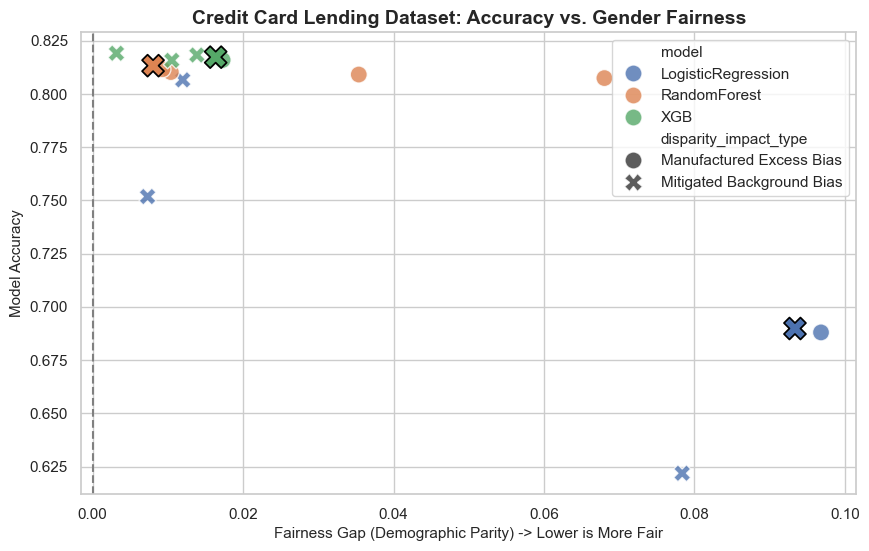

In [8]:
# === CELL 11: CREDIT LENDING VISUALIZATION ===
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# Separate Baselines and Mitigations
baselines = credit_all_mitigations[credit_all_mitigations['miti_method'] == 'Baseline']
mitigations = credit_all_mitigations[credit_all_mitigations['miti_method'] != 'Baseline']

# Plot Mitigations
sns.scatterplot(
    data=mitigations, 
    x='Demographic Parity', 
    y='accuracy', 
    hue='model', 
    style='disparity_impact_type',
    s=150, 
    alpha=0.8
)

# Plot Baselines with a distinct star marker
sns.scatterplot(
    data=baselines, 
    x='Demographic Parity', 
    y='accuracy', 
    hue='model', 
    marker='X', 
    s=250, 
    edgecolor='black', 
    legend=False
)

plt.title("Credit Card Lending Dataset: Accuracy vs. Gender Fairness", fontsize=14, fontweight='bold')
plt.xlabel("Fairness Gap (Demographic Parity) -> Lower is More Fair", fontsize=11)
plt.ylabel("Model Accuracy", fontsize=11)
plt.axvline(x=0.0, color='gray', linestyle='--')

plt.show()

In [9]:
from IPython.display import HTML, display

# 1. Save the file exactly as needed
output_filename = "Credit card_mitigation_detail.csv"
df_detail.to_csv(output_filename, index=False)
print(f"🎉 Partner detail CSV file saved successfully as '{output_filename}'!")

# 2. Generate a downloadable HTML link
html_link = f'<a href="{output_filename}" download="{output_filename}" style="font-weight:bold; color:#1a73e8; font-size:16px;">👉 Click here to download your {output_filename} file</a>'
display(HTML(html_link))

🎉 Partner detail CSV file saved successfully as 'Credit card_mitigation_detail.csv'!


In [10]:
# === NEW CELL: FORMAT AND EXPORT CREDIT CARD PIPELINE RESULTS ===
import pandas as pd
from IPython.display import HTML, display

# 1. Dynamically target the resulting array generated from your credit card mitigation loop
if 'raw_bank_mitigations' in locals() and not raw_bank_mitigations.empty:
    df_results = raw_bank_mitigations.copy()
elif 'all_mitigation_results' in locals() and len(all_mitigation_results) > 0:
    df_results = pd.DataFrame(all_mitigation_results)
else:
    try:
        df_results = bank_all_mitigations.copy()
    except NameError:
        raise NameError("❌ Could not find the execution metrics. Please execute the Cell 6 Loop first!")

# 2. Re-assign demographic attributes to show 'gender' to align with the Credit Card dataset context
df_results['sensitive_attr'] = 'gender'

# 3. Match the structural column layouts specified in your target nhanes sample
columns_layout = [
    "model", "sensitive_attr", "miti_method", "accuracy", 
    "precision", "recall", "f1", "roc_auc", 
    "Equal Opportunity", "Equalized Odds", "Demographic Parity"
]

# Safeguard structural integrity against missing optional logs
valid_columns = [col for col in columns_layout if col in df_results.columns]
df_results = df_results[valid_columns]

# 4. Save locally to the runtime instance
output_csv_name = "credit_card_mitigation_results.csv"
df_results.to_csv(output_csv_name, index=False)
print(f"🎉 Summary metrics dataset compiled successfully as '{output_csv_name}'!")

# 5. Inject a secure, clean hyperlink to trigger browser downloads directly
html_download = f'''
<div style="padding: 10px; background-color: #e8f0fe; border-left: 5px solid #1a73e8; margin: 10px 0;">
    <a href="{output_csv_name}" download="{output_csv_name}" 
       style="font-weight: bold; color: #1a73e8; font-size: 16px; text-decoration: none;">
       👉 Click here to download your {output_csv_name} file
    </a>
</div>
'''
display(HTML(html_download))

# Render preview
df_results.head()

🎉 Summary metrics dataset compiled successfully as 'credit_card_mitigation_results.csv'!


,model,sensitive_attr,miti_method,accuracy,precision,recall,f1,roc_auc,Equal Opportunity,Equalized Odds,Demographic Parity
0,LogisticRegression,gender,Baseline,0.689833,0.375350,0.605878,0.463534,0.659776,0.062077,0.093998,0.093367
1,LogisticRegression,gender,Reweighing,0.688000,0.374250,0.611153,0.464224,0.660488,0.068378,0.096605,0.096833
2,LogisticRegression,gender,ExponentiatedGradient,0.751833,0.447403,0.519216,0.480642,0.668553,0.022482,0.022482,0.007299
3,LogisticRegression,gender,ThresholdOptimizer,0.806667,0.615172,0.336096,0.434698,0.638196,0.069635,0.069635,0.011970
4,LogisticRegression,gender,Suppression,0.621833,0.326711,0.669179,0.439061,0.638784,0.057409,0.077120,0.078377
